In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import itertools

2026-03-02 15:14:56.134909: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 15:14:56.136859: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 15:14:56.173050: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 15:14:56.311319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 15:14:57.085531: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warnin

In [2]:
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [3]:
# carregando o dataset
fm = tf.keras.datasets.fashion_mnist

# carregando os dados
(X_train, y_train), (X_test,y_test) = fm.load_data()

# normalizando os dados (deixando entre 0 e 1)
X_train, X_test = X_train / 255, X_test / 255

In [4]:
# vendo o formato
X_train.shape

(60000, 28, 28)

In [5]:
# expandindo para ter a terceira dimensão (cor)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

X_train.shape, X_test.shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [6]:
# vendo o número de classes de resposta
K = len(set(y_train))
K

10

In [7]:
# fazendo a rede neural com a API funcional
i = Input(shape=X_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [8]:
# compilação
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [9]:
# treinamento
r = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.7451 - loss: 0.7053 - val_accuracy: 0.8488 - val_loss: 0.4037
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8584 - loss: 0.3757 - val_accuracy: 0.8652 - val_loss: 0.3600
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8825 - loss: 0.3161 - val_accuracy: 0.8811 - val_loss: 0.3170
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8952 - loss: 0.2815 - val_accuracy: 0.8856 - val_loss: 0.3158
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9036 - loss: 0.2521 - val_accuracy: 0.8889 - val_loss: 0.3088
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9139 - loss: 0.2281 - val_accuracy: 0.8974 - val_loss: 0.2925
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9216 - loss: 0.2068 - val_accuracy: 0.8947 - val_loss: 0.2951
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9249 - loss: 0.19

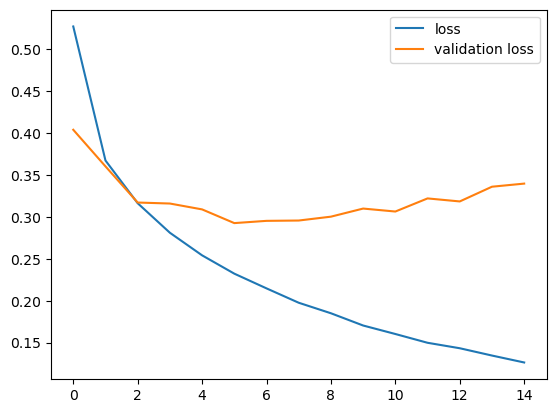

In [10]:
# grafico de comparação loss e validation loss
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='validation loss')
plt.legend()

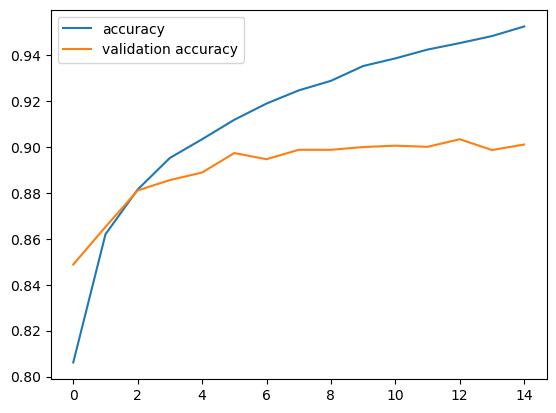

In [11]:
# grafico de comparação da accuracy e validation accuracy
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='validation accuracy')
plt.legend()

In [15]:
# função para mostrar a matriz de confusão
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):

    # a função mostra a matriz de confusao, se normalize for
    # colocado como True, os valores serão normalizados

    if normalize:
        # normaliza os valores
        cm = cm.astype('float') /cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')

    else:
        print('confusion_matrix, without normalization')

    print(cm)

    # passando a matriz de confusão para mostrar    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    # titulo
    plt.title(title)
    # cores
    plt.colorbar()

    # define os nomes das classes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # inserção do texto e formatação
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    # mostra as imagens e labels
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
confusion_matrix, without normalization
[[883   0  17  15   0   1  74   0  10   0]
 [  6 971   0  15   3   0   3   0   1   1]
 [ 19   0 833  10  52   0  82   0   4   0]
 [ 22   5  18 900  30   1  23   0   1   0]
 [  2   1  46  25 846   0  78   0   2   0]
 [  0   0   0   1   0 966   0  26   0   7]
 [129   0  54  25  82   0 698   0  12   0]
 [  0   0   0   0   0   7   0 964   0  29]
 [  4   1   1   2   3   1   4   1 980   3]
 [  1   0   0   0   0   5   0  24   0 970]]


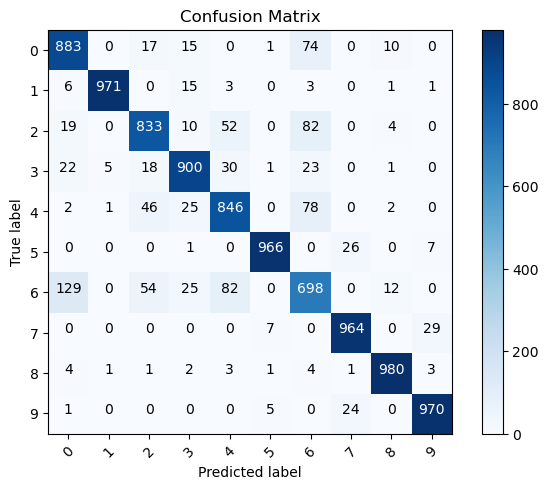

In [16]:
# testando a matriz de confusão
p_test = model.predict(X_test).argmax(axis=1) # fazendo previsões
cm = confusion_matrix(y_test, p_test) # matriz de confusão
plot_confusion_matrix(cm, list(range(10))) # função para mostrar matriz de confusão

In [17]:
# Mapeando as labels
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split()

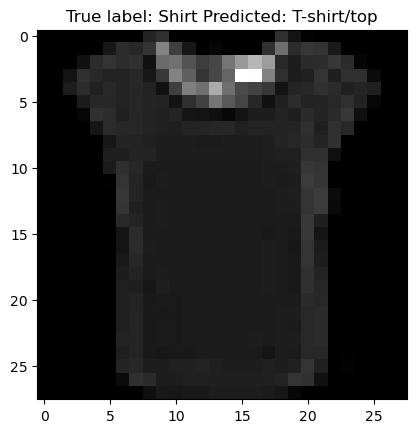

In [19]:
# Mostrando exemplos de erro na predicão
# encontra errors
misclassified_idx = np.where(p_test != y_test)[0]
# errado elatório
i = np.random.choice(misclassified_idx)
# define titulo e mostra a imagem
plt.imshow(X_test[i].reshape(28,28), cmap='gray')
plt.title("True label: %s Predicted: %s" % (labels[y_test[i]], labels[p_test[i]]));